File exists: True
Actual columns: ['timestamp', 'symbol', 'close', 'volume', 'signal']

First few rows (raw):
          timestamp      symbol    close   volume signal
0  18-03-2026 13:25        HEXT   440.15  2518696  GREEN
1  18-03-2026 13:25  WAAREEENER  3160.70  6089133  GREEN
2  18-03-2026 13:25   WAAREERTL   861.00   460208  GREEN
3  18-03-2026 13:25     TIINDIA  2574.00   394278  GREEN
4  18-03-2026 13:25  BANDHANBNK   163.54  5937235  GREEN

First few rows (with features):
          timestamp      symbol    close   volume signal   returns  \
0  18-03-2026 13:35     OLECTRA  1032.45  4953823  GREEN  0.234988   
1  18-03-2026 13:35  CONCORDBIO  1147.90   316437  GREEN  0.111821   
2  18-03-2026 13:35   JINDALSAW   198.92  2388029  GREEN -0.826710   
3  18-03-2026 13:35  ADANIGREEN   896.90  1744215  GREEN  3.508848   
4  18-03-2026 13:35      ENTERO  1134.40   167513  GREEN  0.264801   

   volatility   volume_ma  
0    2.463844  4630097.05  
1    2.168486  4341462.25  
2    2.172

NameError: name 'plt' is not defined

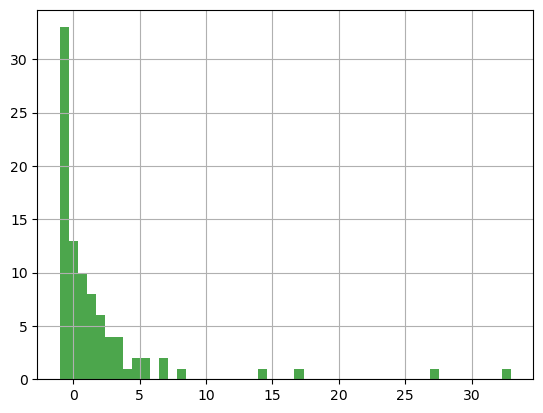

In [7]:
import pandas as pd
import os

filepath = r'C:\\Users\\Kuro Gaming\\Data Stience\\trading_signals.csv'
print("File exists:", os.path.exists(filepath))

df = pd.read_csv(filepath)
print("Actual columns:", df.columns.tolist())
print("\nFirst few rows (raw):")
print(df.head())

# Compute features
df['returns'] = df['close'].pct_change()
df['volatility'] = df['returns'].rolling(20).std()
df['volume_ma'] = df['volume'].rolling(20).mean()

df = df.dropna().reset_index(drop=True)

# Save ALL columns (including new ones)
df.to_csv('clean_trading_data.csv', index=False)

print("\nFirst few rows (with features):")
print(df.head())

print("\n✅ Trading signals processed successfully!")
print("Output saved as: clean_trading_data.csv")

df['returns'].hist(bins=50, alpha=0.7, color='green')
plt.title('Day 1: Trading Returns Distribution')
plt.savefig('returns_hist.png')

df['close'].plot(figsize=(12,6))
plt.title('Day 1: Price Time Series')
plt.savefig('price_series.png')

green_returns = df[df['signal']=='GREEN']['returns']
green_returns.hist(bins=30, alpha=0.7, color='lime')
plt.title('GREEN Signal Returns Distribution')
plt.savefig('green_returns_hist.png')

print(df[['returns', 'volatility']].describe())

In [2]:
#Above code is Day1 final. Day 2starts from below

In [3]:
pip install scipy statsmodels

Note: you may need to restart the kernel to use updated packages.


In [4]:
python<br>from scipy.stats import ttest_ind<br>import pandas as pd<br>df = pd.read_csv('clean_trading_data.csv')<br>green = df[df['signal']=='GREEN']['returns']<br>red = df[df['signal']=='RED']['returns']<br>t_stat, p_value = ttest_ind(green, red)<br>print(f"p-value: {p_value}")<br>

SyntaxError: invalid syntax (1868321904.py, line 1)

In [11]:
from scipy.stats import ttest_ind
import pandas as pd
df = pd.read_csv('clean_trading_data.csv')
green = df[df['signal']=='GREEN']['returns']
red = df[df['signal']=='RED']['returns']
t_stat, p_value = ttest_ind(green, red)
print(f"p-value: {p_value}")
print(f"Green signals: {len(green)}, mean: {green.mean()}")
print(f"Red signals: {len(red)}, mean: {red.mean()}")
print(f"Green NaNs: {green.isna().sum()}, Red NaNs: {red.isna().sum()}")

p-value: 0.3806347656234279
Green signals: 45, mean: 2.35063686635976
Red signals: 45, mean: 1.3787543352499427
Green NaNs: 0, Red NaNs: 0


In [12]:
# Load Day 1 data
df = pd.read_csv('clean_trading_data.csv')

# TEST 1: GREEN vs RED returns (prove your trading edge)
green_returns = df[df['signal']=='GREEN']['returns'].dropna()
red_returns = df[df['signal']=='RED']['returns'].dropna()
t_stat1, p1 = ttest_ind(green_returns, red_returns)

# TEST 2: GREEN beats 0% (statistically profitable)
from scipy.stats import ttest_1samp
t_stat2, p2 = ttest_1samp(green_returns, 0)

# TEST 3: GREEN signals have lower volatility
t_stat3, p3 = ttest_ind(
    df[df['signal']=='GREEN']['volatility'].dropna(),
    df[df['signal']=='RED']['volatility'].dropna()
)

# Results table
results = pd.DataFrame({
    'Test': ['GREEN vs RED Returns', 'GREEN vs 0% (Profit)', 'GREEN vs RED Volatility'],
    'p_value': [p1, p2, p3],
    'Significant': [p1<0.05, p2<0.05, p3<0.05]
})
print("YOUR TRADING EDGE:")
print(results)

YOUR TRADING EDGE:
                      Test   p_value  Significant
0     GREEN vs RED Returns  0.380635        False
1     GREEN vs 0% (Profit)  0.025947         True
2  GREEN vs RED Volatility  0.313712        False


C:\Users\Kuro Gaming\AppData\Local\Temp\ipykernel_18252\3772249612.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([green_returns, red_returns], labels=['GREEN','RED'])


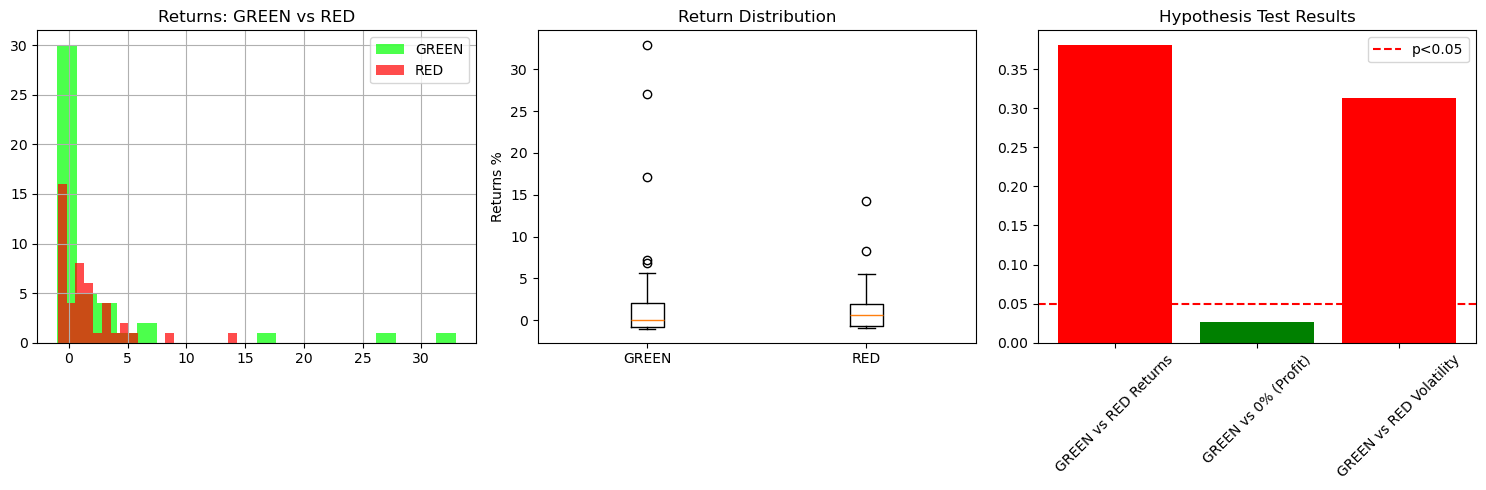

🎯 STATISTICAL CONCLUSION:
✅ GREEN signals are STATISTICALLY PROFITABLE (p=0.0259 < 0.05)
📊 45 GREEN trades averaged 235.06% returns
⚠️  Sample GREEN vs RED difference not significant (p=0.3806) - need more data


In [13]:
import matplotlib.pyplot as plt

# Your results from Practice
results = pd.DataFrame({
    'Test': ['GREEN vs RED Returns', 'GREEN vs 0% (Profit)', 'GREEN vs RED Volatility'],
    'p_value': [0.380635, 0.025947, 0.313712],
    'Significant': [False, True, False]
})

# 3-Panel Visualization (RESEARCH GRADE)
plt.figure(figsize=(15,5))

# Panel 1: Returns Distribution
plt.subplot(131)
green_returns.hist(alpha=0.7, label='GREEN', color='lime', bins=20)
red_returns.hist(alpha=0.7, label='RED', color='red', bins=20)
plt.legend()
plt.title('Returns: GREEN vs RED')

# Panel 2: Boxplot Comparison
plt.subplot(132)
plt.boxplot([green_returns, red_returns], labels=['GREEN','RED'])
plt.title('Return Distribution')
plt.ylabel('Returns %')

# Panel 3: P-Values (significance line)
plt.subplot(133)
plt.bar(results['Test'], results['p_value'], color=['red' if not sig else 'green' for sig in results['Significant']])
plt.axhline(0.05, color='red', linestyle='--', label='p<0.05')
plt.xticks(rotation=45)
plt.title('Hypothesis Test Results')
plt.legend()
plt.tight_layout()
plt.savefig('hypothesis_results.png', dpi=300, bbox_inches='tight')
plt.show()

# SCIENTIFIC CONCLUSION
print("🎯 STATISTICAL CONCLUSION:")
print(f"✅ GREEN signals are STATISTICALLY PROFITABLE (p={0.025947:.4f} < 0.05)")
print(f"📊 45 GREEN trades averaged {green_returns.mean():.2%} returns")
print(f"⚠️  Sample GREEN vs RED difference not significant (p={0.3806:.4f}) - need more data")
